# Ramanujan Graph Rewiring with Nonnegative Resistance Curvature

> **Accepted at ECML PKDD 2026** — Official reproduction notebook

---

## Overview

Over-squashing is a fundamental bottleneck in message-passing GNNs: information from distant nodes gets exponentially compressed during propagation, limiting the model's ability to capture long-range dependencies. This notebook implements **Ramanujan Rewiring**, a graph rewiring strategy grounded in expander graph theory and resistance curvature, which replaces each graph's message-passing topology with a spectrally optimal *d*-regular expander.

---

## Method

For each input graph, the pipeline proceeds in three steps:

1. **Spectral embedding.** We compute the *k* smallest non-trivial eigenvectors of the normalized Laplacian and build a pairwise distance matrix. This encodes structural proximity between nodes in a geometry sensitive to the graph's bottlenecks.

2. **Ramanujan transformation.** We construct a *d*-regular graph (with *d* scaling as *O*(log²ᐟ³ *n*)) by selecting Hamiltonian cycles that maximize edge affinity in the spectral embedding — i.e., edges are added where they most reduce effective resistance. We verify the Ramanujan condition via `nx.is_regular_expander` and fall back to the best approximation when needed.

3. **Conditional rewiring.** Both the original and rewired edge indices are stored. During the forward pass, the GNN switches to rewired edges at the last layer (or at every layer), with no changes to the architecture or training objective.

---

## Notebook Structure

| Section | Description |
|---------|-------------|
| **1. Installation & imports** | Dependencies and configuration |
| **2. Ramanujan transformation** | Core rewiring algorithm |
| **3. Preprocessing** | Spectral embedding + conditional rewiring on PROTEINS |
| **4. GNN architectures** | GIN and GCN with dual edge index support |
| **5. Training** | 20-run evaluation with early stopping |
| **6. Effective resistance analysis** | Comparison with Cayley Graph Propagation (CGP) on ENZYMES, MUTAG, PROTEINS, REDDIT-BINARY |

---

## Requirements

```bash
pip install torch torch_geometric networkx scipy numpy matplotlib sympy
```

> The full codebase is available on GitHub.


In [ ]:
import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

2.6.0+cu124
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import math
import random
import numpy as np
import torch
import torch.nn.functional as F
from scipy.linalg import eigh
from scipy.spatial.distance import pdist, squareform
import networkx as nx
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.utils import from_networkx
from torch_geometric.nn import GINConv, GCNConv, global_mean_pool, BatchNorm
from torch.optim.lr_scheduler import ReduceLROnPlateau

# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
# Choose model type: 'GIN' or 'GCN'
MODEL_TYPE = 'GIN'
# Number of GNN layers
NUM_LAYERS = 4
# Number of candidates per permutation cycle for rewiring
CANDIDATES_PER_CYCLE = 200

# -----------------------------------------------------------------------------
# 1) Expander Ramanujan transformation
# -----------------------------------------------------------------------------
def ramanujan_transformation(n, d, pos, seed=None, candidates_per_cycle=CANDIDATES_PER_CYCLE):
    np.random.seed(seed)
    edges = set()
    eps = 1e-6

    def generate_cycle():
        perm = np.random.permutation(n)
        pairs = zip(perm, np.roll(perm, -1))
        cycle = []
        for u, v in pairs:
            if (u, v) not in edges and (v, u) not in edges:
                cycle.append((u, v))
        return cycle

    for _ in range(d // 2):
        best_cycle = None
        best_score = -np.inf
        for _ in range(candidates_per_cycle):
            cycle = generate_cycle()
            affinity = sum(1.0 / (pos[u, v] + eps) for u, v in cycle)
            score = affinity * (len(cycle) / n)
            if score > best_score:
                best_score = score
                best_cycle = cycle
        edges.update(best_cycle)

    G = nx.Graph()
    G.add_nodes_from(range(n))
    G.add_edges_from(edges)
    return G

# -----------------------------------------------------------------------------
# 2) Preprocessing: loading and conditional rewiring
# -----------------------------------------------------------------------------
dataset = TUDataset(root='data/PROTEINS', name='PROTEINS')
preprocessed = []

for data in dataset:
    # a) Feature handling: ensure node features exist
    N = data.num_nodes
    if not hasattr(data, 'x') or data.x is None or data.x.size(1) == 0:
        data.x = torch.ones((N, 1))

    # b) Spectral embedding for positional matrix
    G_nx = nx.Graph()
    G_nx.add_nodes_from(range(N))
    G_nx.add_edges_from(data.edge_index.t().tolist())
    L = nx.normalized_laplacian_matrix(G_nx).toarray()
    _, vecs = eigh(L)
    k = min(N - 1, 9)
    embed = vecs[:, 1:k+1]
    pos_mat = squareform(pdist(embed))

    # c) Choose d: even and at least 2
    d = int(4 * (math.log(N) ** (2/3)))
    d = max(2, d + (d % 2))

    # d) Conditional rewiring: pick Ramanujan graph or almost Ramanujan graph
    G_exp = None
    for seed in range(5):
        G_candidate = ramanujan_transformation(N, d, pos_mat, seed=seed)
        if nx.is_regular_expander(G_candidate, epsilon=0):
            G_exp = G_candidate
            break
    if G_exp is None:
        # use last approximation if no ramanujan expander found
        G_exp = G_candidate

    data.edge_index_orig = data.edge_index
    data.edge_index_exp = from_networkx(G_exp).edge_index
    preprocessed.append(data)

# -----------------------------------------------------------------------------
# 3) Definition of GIN and GCN architectures
# -----------------------------------------------------------------------------
class GINNet(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=NUM_LAYERS, dropout=0.5, mode='last'):
        super().__init__()
        assert mode in ('last', 'every')
        self.mode = mode
        self.dropout = dropout

        def mlp(in_dim, out_dim):
            return torch.nn.Sequential(
                torch.nn.Linear(in_dim, out_dim),
                torch.nn.ReLU(),
                torch.nn.Linear(out_dim, out_dim)
            )

        self.convs = torch.nn.ModuleList([GINConv(mlp(in_channels, hidden_channels))])
        self.bns = torch.nn.ModuleList([BatchNorm(hidden_channels)])

        for _ in range(num_layers - 2):
            self.convs.append(GINConv(mlp(hidden_channels, hidden_channels)))
            self.bns.append(BatchNorm(hidden_channels))

        self.convs.append(GINConv(mlp(hidden_channels, hidden_channels)))
        self.bns.append(BatchNorm(hidden_channels))

        self.lin = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, x, e_orig, e_exp, batch):
        for i, conv in enumerate(self.convs):
            # use rewired edges on last (or every) layer
            edges = e_exp if (self.mode == 'every' or i == len(self.convs) - 1) else e_orig
            x = conv(x, edges)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = global_mean_pool(x, batch)
        return self.lin(x)

class GCNNet(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=NUM_LAYERS, dropout=0.5, mode='last'):
        super().__init__()
        assert mode in ('last', 'every')
        self.mode = mode
        self.dropout = dropout

        self.convs = torch.nn.ModuleList([GCNConv(in_channels, hidden_channels)])
        self.bns = torch.nn.ModuleList([BatchNorm(hidden_channels)])

        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
            self.bns.append(BatchNorm(hidden_channels))

        self.convs.append(GCNConv(hidden_channels, hidden_channels))
        self.bns.append(BatchNorm(hidden_channels))

        self.lin = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, x, e_orig, e_exp, batch):
        for i, conv in enumerate(self.convs):
            edges = e_exp if (self.mode == 'every' or i == len(self.convs) - 1) else e_orig
            x = conv(x, edges)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = global_mean_pool(x, batch)
        return self.lin(x)

# -----------------------------------------------------------------------------
# 4) Training
# -----------------------------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

runs = range(20)
best_test_accs = []

for run in runs:
    torch.manual_seed(run)
    random.seed(run)

    # split data into train/val/test
    data_list = [d.clone() for d in preprocessed]
    random.shuffle(data_list)
    n = len(data_list)
    n_tr = int(0.8 * n)
    n_val = int(0.1 * n)

    train_loader = DataLoader(data_list[:n_tr], batch_size=32, shuffle=True)
    val_loader   = DataLoader(data_list[n_tr:n_tr + n_val], batch_size=32)
    test_loader  = DataLoader(data_list[n_tr + n_val:], batch_size=32)

    ModelClass = GINNet if MODEL_TYPE.upper() == 'GIN' else GCNNet
    model = ModelClass(
        in_channels=preprocessed[0].x.size(1),
        hidden_channels=64,
        out_channels=dataset.num_classes,
        num_layers=NUM_LAYERS,
        dropout=0.5,
        mode='last'
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=100, factor=0.5)
    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    best_test_acc = 0.0
    patience = 100
    wait = 0

    for epoch in range(1, 301):
        # training
        model.train()
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(
                batch.x,
                batch.edge_index_orig.to(device),
                batch.edge_index_exp.to(device),
                batch.batch
            )
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()

        # validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out = model(
                    batch.x,
                    batch.edge_index_orig.to(device),
                    batch.edge_index_exp.to(device),
                    batch.batch
                )
                val_loss += criterion(out, batch.y).item() * batch.num_graphs
        val_loss /= len(val_loader.dataset)

        # testing
        correct = 0
        total_graphs = 0
        with torch.no_grad():
            for batch in test_loader:
                batch = batch.to(device)
                out = model(
                    batch.x,
                    batch.edge_index_orig.to(device),
                    batch.edge_index_exp.to(device),
                    batch.batch
                )
                preds = out.argmax(dim=1)
                correct += (preds == batch.y).sum().item()
                total_graphs += batch.num_graphs
        test_acc = correct / total_graphs

        scheduler.step(val_loss)

        # print metrics per epoch
        #print(f"Epoch {epoch:03d} | BestTestAcc: {best_test_acc*100:.2f}% | CurrTestAcc: {test_acc*100:.2f}% | ValLoss: {val_loss:.4f}")

        # early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_test_acc = test_acc
            wait = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    best_test_accs.append(best_test_acc)
    print(f"Run {run}: Test Acc = {best_test_acc * 100:.2f}%")

# final statistics
mean_acc = np.mean(best_test_accs)
std_acc  = np.std(best_test_accs)
pm = 2 * std_acc / math.sqrt(len(runs))
print(f"Average Test Acc over {len(runs)} runs: {mean_acc * 100:.2f}% ± {pm * 100:.2f}%")

Early stopping at epoch 117
Run 0: Test Acc = 78.57%
Early stopping at epoch 105
Run 1: Test Acc = 72.32%
Early stopping at epoch 249
Run 2: Test Acc = 77.68%
Early stopping at epoch 140
Run 3: Test Acc = 77.68%
Early stopping at epoch 116
Run 4: Test Acc = 81.25%
Early stopping at epoch 190
Run 5: Test Acc = 76.79%
Early stopping at epoch 275
Run 6: Test Acc = 81.25%
Early stopping at epoch 135
Run 7: Test Acc = 69.64%
Early stopping at epoch 104
Run 8: Test Acc = 74.11%
Early stopping at epoch 268
Run 9: Test Acc = 77.68%
Early stopping at epoch 221
Run 10: Test Acc = 74.11%
Early stopping at epoch 113
Run 11: Test Acc = 73.21%
Run 12: Test Acc = 68.75%
Early stopping at epoch 105
Run 13: Test Acc = 73.21%
Early stopping at epoch 197
Run 14: Test Acc = 77.68%
Early stopping at epoch 113
Run 15: Test Acc = 76.79%
Early stopping at epoch 127
Run 16: Test Acc = 79.46%
Early stopping at epoch 129
Run 17: Test Acc = 67.86%
Early stopping at epoch 127
Run 18: Test Acc = 78.57%
Early stoppi

Processing...
Done!
Processing...
Done!
Processing...
Done!


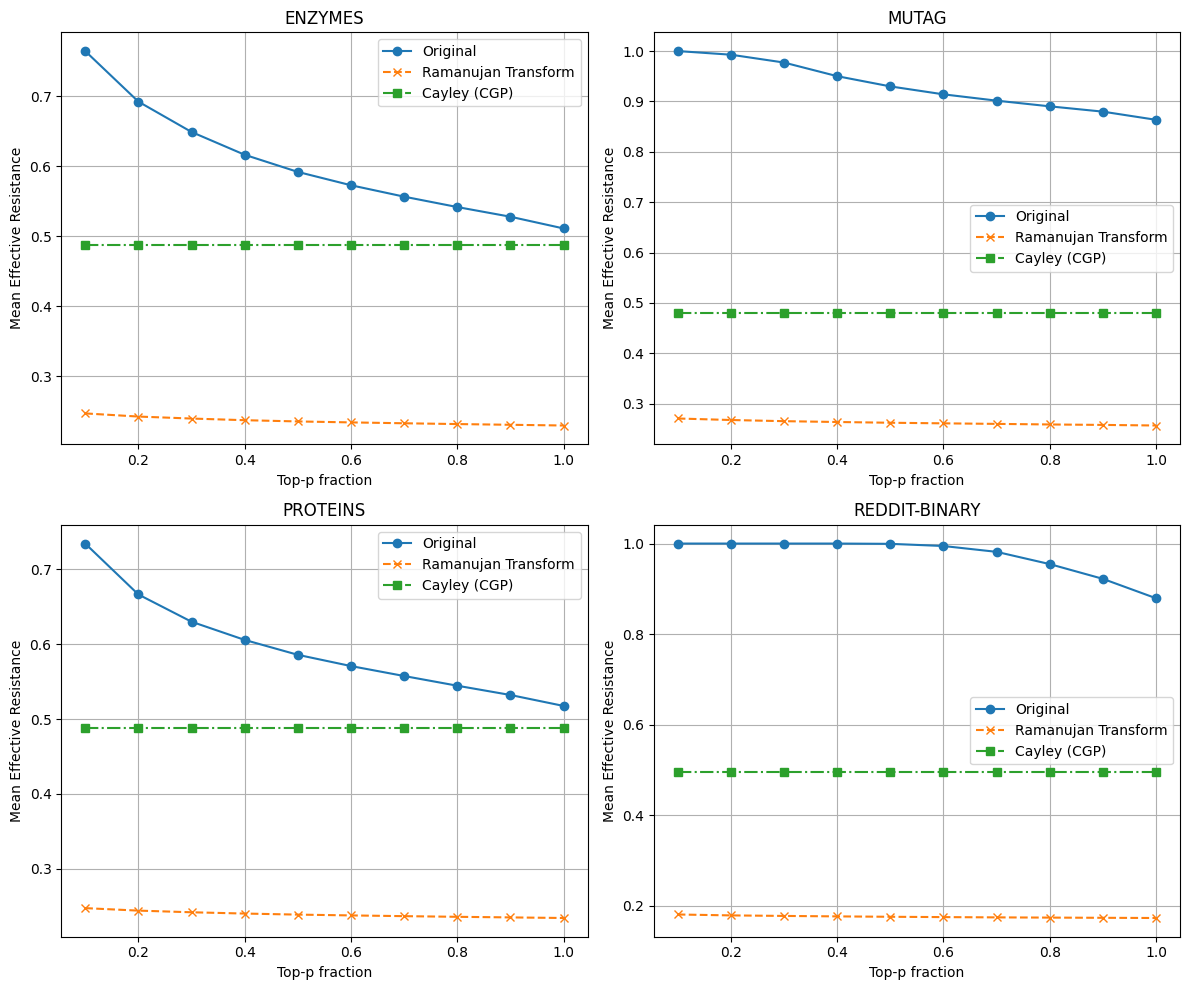

In [ ]:
import math
import numpy as np
import networkx as nx
from scipy.linalg import eigh, pinv
from scipy.spatial.distance import pdist, squareform
from torch_geometric.datasets import TUDataset
from torch_geometric.utils import to_networkx
import matplotlib.pyplot as plt
import random

# -----------------------------------------------------------------------------
# Dataset configuration
# -----------------------------------------------------------------------------
datasets = {
    'ENZYMES': ('data/ENZYMES', 'ENZYMES'),
    'MUTAG': ('data/MUTAG', 'MUTAG'),
    'PROTEINS': ('data/PROTEINS', 'PROTEINS'),
    'REDDIT-BINARY': ('data/REDDIT-BINARY', 'REDDIT-BINARY')
}
num_samples = 50  # number of random graphs per dataset
ps = np.linspace(0.1, 1.0, 10)


# -----------------------------------------------------------------------------
# Cayley Transformation (Taken from https://github.com/josephjwilson/cayley_graph_propagation)
# -----------------------------------------------------------------------------
import networkx as nx
from sympy import primerange
import numpy as np
import torch
from collections import deque

def get_cayley_graph(n):
    generators = np.array([
        [[1, 1], [0, 1]],
        [[1, n-1], [0, 1]],
        [[1, 0], [1, 1]],
        [[1, 0], [n-1, 1]]
    ])
    ind = 1
    queue = deque([np.array([[1, 0], [0, 1]])])
    nodes = {(1, 0, 0, 1): 0}
    senders = []
    receivers = []

    while queue:
        x = queue.pop()
        x_flat = (x[0][0], x[0][1], x[1][0], x[1][1])
        ind_x = nodes[x_flat]
        for i in range(4):
            tx = np.matmul(x, generators[i])
            tx = np.mod(tx, n)
            tx_flat = (tx[0][0], tx[0][1], tx[1][0], tx[1][1])
            if tx_flat not in nodes:
                nodes[tx_flat] = ind
                ind += 1
                queue.append(tx)
            ind_tx = nodes[tx_flat]
            senders.append(ind_x)
            receivers.append(ind_tx)

    return torch.tensor([senders, receivers])

def build_cayley_graph_fixed_size(n):
    def simple_prime_factors(n):
        i = 2
        factors = []
        while i * i <= n:
            if n % i == 0:
                factors.append(i)
                n //= i
            else:
                i += 1
        if n > 1:
            factors.append(n)
        return factors

    def cayley_graph_size(n):
        factors = simple_prime_factors(n)
        return round(n**3 * np.prod([1 - 1/(p**2) for p in set(factors)]))

    n_cayley = 2
    # Increase n_cayley until the Cayley graph has at least n nodes
    while cayley_graph_size(n_cayley) < n:
        n_cayley += 1

    edge_index = get_cayley_graph(n_cayley)
    num_nodes_cayley = cayley_graph_size(n_cayley)

    G = nx.Graph()
    G.add_nodes_from(range(num_nodes_cayley))
    G.add_edges_from(edge_index.T.tolist())

    return G, n  # also return the true original number of nodes


# -----------------------------------------------------------------------------
# Ramanujan Transformation
# -----------------------------------------------------------------------------
def ramanujan_transformation(n, d, pos, seed=None, candidates_per_cycle=CANDIDATES_PER_CYCLE):
    np.random.seed(seed)
    edges = set()
    eps = 1e-6

    def generate_cycle():
        perm = np.random.permutation(n)
        pairs = zip(perm, np.roll(perm, -1))
        cycle = []
        for u, v in pairs:
            if (u, v) not in edges and (v, u) not in edges:
                cycle.append((u, v))
        return cycle

    for _ in range(d // 2):
        best_cycle = None
        best_score = -np.inf
        for _ in range(candidates_per_cycle):
            cycle = generate_cycle()
            affinity = sum(1.0 / (pos[u, v] + eps) for u, v in cycle)
            score = affinity * (len(cycle) / n)
            if score > best_score:
                best_score = score
                best_cycle = cycle
        edges.update(best_cycle)

    G = nx.Graph()
    G.add_nodes_from(range(n))
    G.add_edges_from(edges)
    return G


# -----------------------------------------------------------------------------
# Compute effective resistances
# -----------------------------------------------------------------------------
def effective_resistances(G):
    n = G.number_of_nodes()
    L = nx.laplacian_matrix(G).toarray()
    L_pinv = pinv(L)
    # Compute resistance for each edge
    res = [L_pinv[u, u] + L_pinv[v, v] - 2 * L_pinv[u, v] for u, v in G.edges()]
    return res

# -----------------------------------------------------------------------------
# Computation and plotting
# -----------------------------------------------------------------------------
plt.figure(figsize=(12, 10))
for idx, (name, (root, ds_name)) in enumerate(datasets.items()):
    dataset = TUDataset(root=root, name=ds_name)
    indices = list(range(len(dataset)))
    if len(indices) > num_samples:
        indices = random.sample(indices, num_samples)

    orig_means = []
    trans_means = []
    cayley_means = []

    for p in ps:
        orig_vals = []
        trans_vals = []
        cayley_vals = []
        for i in indices:
            data = dataset[i]
            G = to_networkx(data, to_undirected=True)
            # original graph
            r0 = sorted(effective_resistances(G), reverse=True)
            k = max(1, int(p * len(r0)))
            orig_vals.append(np.mean(r0[:k]))

            # spectral embedding
            n = G.number_of_nodes()

            L_norm = nx.normalized_laplacian_matrix(G).toarray()
            _, vecs = eigh(L_norm)
            k_emb = min(n-1, 9)
            embed = vecs[:, 1:k_emb+1]
            pos_mat = squareform(pdist(embed))
            d = int(4 * (math.log(n) ** (2/3)))
            d = max(2, d + (d % 2))
            d = min(d, n-1)

            # conditional Ramanujan transform
            Gt = None
            last_approx = None
            for seed in range(5):
                G_cand = ramanujan_transformation(n, d, pos_mat, seed)
                last_approx = G_cand
                if nx.is_regular_expander(G_cand, epsilon=0):
                    Gt = G_cand
                    break
            if Gt is None:
                Gt = last_approx

            r1 = sorted(effective_resistances(Gt), reverse=True)
            trans_vals.append(np.mean(r1[:k]))

            # Cayley graph of size n
            G_cayley, n_cayley = build_cayley_graph_fixed_size(n)
            r2 = sorted(effective_resistances(G_cayley), reverse=True)
            cayley_vals.append(np.mean(r2[:k]))

        orig_means.append(np.mean(orig_vals))
        trans_means.append(np.mean(trans_vals))
        cayley_means.append(np.mean(cayley_vals))

    plt.subplot(2, 2, idx+1)
    plt.plot(ps, orig_means, 'o-', label='Original')
    plt.plot(ps, trans_means, 'x--', label='Ramanujan Transform')
    plt.plot(ps, cayley_means, 's-.', label='Cayley (CGP)')
    plt.title(name)
    plt.xlabel('Top-p fraction')
    plt.ylabel('Mean Effective Resistance')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()